## **Modelos Transformer para Classificação de Texto**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

1. **Comparação de modelos pré-treinados** — BERT, DistilBERT, RoBERTa
2. **Estratégias de fine-tuning** — Frozen, Parcial (últimas N camadas), Completo
3. **Stratified K-Fold (K=5)** — Comparação robusta
4. **Grid Search** — LR × Epochs × Estratégia de freeze no melhor modelo
5. **Retreino e avaliação final** no dataset do professor

### **1. Imports e Configuração**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time
from sklearn.metrics import confusion_matrix, classification_report
from transformers import (
    BertTokenizer, BertModel,
    DistilBertTokenizer, DistilBertModel,
    RobertaTokenizer, RobertaModel,
    get_linear_schedule_with_warmup
)

sys.path.append(os.path.abspath('../src'))
from utils import stratified_k_fold, train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 4070
  VRAM: 12.9 GB


### **2. Carregamento dos Dados**

In [ ]:
print('A carregar os datasets...')

df_main = pd.read_csv('../database/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

df_test = pd.read_csv('../database/dataset-test.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

class_names = sorted(set(labels))
label2idx = {l: i for i, l in enumerate(class_names)}
idx2label = {i: l for l, i in label2idx.items()}
num_classes = len(class_names)

y_all = np.array([label2idx[l] for l in labels])
y_test = np.array([label2idx[l] for l in labels_test])

print(f'  Treino: {len(textos)} textos')
print(f'  Teste: {len(textos_test)} textos')
print(f'  Classes: {class_names}')

A carregar os datasets...
  Treino: 122835 textos
  Teste: 225 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Definição dos Modelos**

Três famílias de transformers pré-treinados, cada uma com duas estratégias de fine-tuning:

| Modelo | Variantes | Hiperparâmetro explorado |
|--------|-----------|--------------------------|
| **BERT base** | Frozen, Fine-tune | Estratégia de freeze |
| **DistilBERT** | Frozen, Fine-tune | Modelo mais leve (40% menos params) |
| **RoBERTa** | Frozen, Fine-tune | Treino mais robusto que BERT |

Frozen = só classificador treinável. Fine-tune = últimas 2 camadas do encoder + classificador.

In [3]:
# Modelos pré-treinados

MODELS = {
    'bert-base-uncased': (BertTokenizer, BertModel, 'bert'),
    'distilbert-base-uncased': (DistilBertTokenizer, DistilBertModel, 'distilbert'),
    'roberta-base': (RobertaTokenizer, RobertaModel, 'roberta'),
}

class TransformerClassifier(nn.Module):
    """
    Classificador genérico com qualquer modelo HuggingFace (encoder-only).

    freeze_strategy:
      'full'    → todo o encoder congelado, só treina classificador
      'partial' → últimas N camadas descongeladas + classificador
      'none'    → tudo descongelado (fine-tune completo)
    """
    def __init__(self, model_name, num_classes, freeze_strategy='partial',
                 unfreeze_last_n=2, classifier_dropout=0.3):
        super().__init__()
        self.model_name = model_name
        self.freeze_strategy = freeze_strategy

        _, model_class, self.model_type = MODELS[model_name]
        self.encoder = model_class.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        # ── Estratégia de freeze ──
        if freeze_strategy == 'full':
            for param in self.encoder.parameters():
                param.requires_grad = False
        elif freeze_strategy == 'partial':
            for param in self.encoder.parameters():
                param.requires_grad = False
            # Descongelar últimas N camadas
            if self.model_type == 'bert':
                layers = self.encoder.encoder.layer
            elif self.model_type == 'distilbert':
                layers = self.encoder.transformer.layer
            elif self.model_type == 'roberta':
                layers = self.encoder.encoder.layer
            for layer in layers[-unfreeze_last_n:]:
                for param in layer.parameters():
                    param.requires_grad = True
        # 'none' → tudo descongelado

        self.classifier = nn.Sequential(
            nn.Dropout(classifier_dropout),
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(classifier_dropout * 0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] token para BERT/RoBERTa, primeiro token para DistilBERT
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

# Verificar parâmetros 
for mname in MODELS:
    m = TransformerClassifier(mname, num_classes, freeze_strategy='partial')
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{mname:30s} | Total: {total/1e6:.0f}M | Treináveis (partial): {trainable/1e6:.1f}M')
    del m

torch.cuda.empty_cache() if torch.cuda.is_available() else None
print('\nModelos definidos.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bert-base-uncased              | Total: 110M | Treináveis (partial): 14.3M


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


distilbert-base-uncased        | Total: 66M | Treináveis (partial): 14.3M


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-base                   | Total: 125M | Treináveis (partial): 14.3M

Modelos definidos.


### **4. Validação Cruzada — Stratified K-Fold (K=5)**

Para cada modelo × estratégia de freeze, tokenizamos com o tokenizer respetivo
e avaliamos com K-Fold. Cada transformer tem o seu tokenizer — não são intercambiáveis.

In [4]:
K = 3  # K=3 para 122k textos
MAX_LEN = 128  # Textos de 80-120 palavras ≈ 100-130 subtokens (256 desperdiçava VRAM)
BATCH_SIZE = 16  # RTX 4070 12GB VRAM
EPOCHS_KFOLD = 3
EPOCHS_FINAL = 4
CHECKPOINT_DIR = '../models/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def tokenize_texts(texts, tokenizer, max_len):
    enc = tokenizer(
        texts, add_special_tokens=True, max_length=max_len,
        padding='max_length', truncation=True,
        return_attention_mask=True, return_tensors='pt')
    return enc['input_ids'], enc['attention_mask']

def eval_batched(model, ids, mask, labels_np, batch_size=64):
    """Avaliação em batches para não rebentar a VRAM."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    total_loss = 0; total = 0
    with torch.no_grad():
        for i in range(0, len(labels_np), batch_size):
            b_ids = ids[i:i+batch_size].to(device)
            b_mask = mask[i:i+batch_size].to(device)
            b_y = torch.LongTensor(labels_np[i:i+batch_size]).to(device)
            out = model(b_ids, b_mask)
            total_loss += criterion(out, b_y).item() * b_y.size(0)
            all_preds.append(torch.argmax(out, 1).cpu())
            total += b_y.size(0)
            del b_ids, b_mask, b_y, out
    preds = torch.cat(all_preds).numpy()
    acc = (preds == labels_np).mean()
    avg_loss = total_loss / total
    return acc, avg_loss

def train_transformer(model, tr_ids, tr_mask, tr_labels,
                      vl_ids, vl_mask, vl_labels,
                      epochs=3, lr=2e-5, batch_size=16, warmup_ratio=0.1,
                      checkpoint_path=None):
    """Treina transformer com mixed precision, tqdm, e checkpoints."""
    from tqdm.auto import tqdm

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=0.01)

    # Dados de treino ficam em CPU, só vão para GPU em batches
    train_ds = TensorDataset(tr_ids, tr_mask, torch.LongTensor(tr_labels))
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=True)

    total_steps = len(loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

    # Mixed precision para poupar VRAM
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    use_amp = device.type == 'cuda'

    best_val_acc = 0; best_state = None
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0; correct = 0; total = 0

        pbar = tqdm(loader, desc=f'Ep {epoch+1}/{epochs}', leave=False)
        for b_ids, b_mask, b_y in pbar:
            b_ids = b_ids.to(device)
            b_mask = b_mask.to(device)
            b_y = b_y.to(device)

            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda'):
                    out = model(b_ids, b_mask)
                    loss = criterion(out, b_y)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(b_ids, b_mask)
                loss = criterion(out, b_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            total_loss += loss.item() * b_y.size(0)
            correct += (torch.argmax(out, 1) == b_y).sum().item()
            total += b_y.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.2%}')
            del b_ids, b_mask, b_y, out, loss

        train_acc = correct / total
        train_loss = total_loss / total

        # Validação em batches (não rebenta a VRAM)
        val_acc, val_loss = eval_batched(model, vl_ids, vl_mask, vl_labels)

        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            # Guardar checkpoint
            if checkpoint_path:
                torch.save(best_state, checkpoint_path)
                tqdm.write(f'      💾 Checkpoint guardado ({val_acc:.2%})')

        tqdm.write(f'      Ep {epoch+1}/{epochs} | Train {train_acc:.2%} | Val {val_acc:.2%}')
        torch.cuda.empty_cache()

    if best_state:
        model.load_state_dict(best_state)
        model = model.to(device)

    return best_val_acc, history

print('Funções definidas (com mixed precision, tqdm, checkpoints).')

Funções definidas (com mixed precision, tqdm, checkpoints).


In [5]:
from tqdm.auto import tqdm

print('=' * 60)
print('Stratified K-Fold Cross-Validation')
print('=' * 60)

cv_results = {}

# Configs: modelo × estratégia
configs = []
for mname in MODELS:
    short = mname.split('-')[0].upper()
    if short == 'DISTILBERT': short = 'DistilBERT'
    configs.append((f'{short} (frozen)',   mname, 'full',    1e-3))
    configs.append((f'{short} (partial)',  mname, 'partial', 2e-5))

global_start = time.time()

for cfg_idx, (nome, mname, freeze_strat, lr) in enumerate(configs):
    print(f'\n[{cfg_idx+1}/{len(configs)}] {nome}:')

    # Tokenizar apenas este modelo (liberta RAM dos outros)
    print(f'  A tokenizar {mname}...')
    tok_class, _, _ = MODELS[mname]
    tokenizer = tok_class.from_pretrained(mname)
    ids_all, mask_all = tokenize_texts(textos, tokenizer, MAX_LEN)
    ids_test, mask_test = tokenize_texts(textos_test, tokenizer, MAX_LEN)

    accs = []
    for fold, (tr_idx, vl_idx) in enumerate(stratified_k_fold(labels, n_splits=K)):
        print(f'    Fold {fold+1}/{K}:')
        tr_ids = ids_all[tr_idx]; tr_mask = mask_all[tr_idx]
        vl_ids = ids_all[vl_idx]; vl_mask = mask_all[vl_idx]

        torch.manual_seed(42)
        model = TransformerClassifier(mname, num_classes, freeze_strategy=freeze_strat)

        ckpt_path = os.path.join(CHECKPOINT_DIR, f'{nome}_fold{fold+1}.pth')
        acc, _ = train_transformer(model, tr_ids, tr_mask, y_all[tr_idx],
                                   vl_ids, vl_mask, y_all[vl_idx],
                                   epochs=EPOCHS_KFOLD, lr=lr, batch_size=BATCH_SIZE,
                                   checkpoint_path=ckpt_path)
        accs.append(acc)
        print(f'    → {acc:.2%}')
        del model; torch.cuda.empty_cache()

    cv_results[nome] = np.array(accs)
    elapsed = (time.time() - global_start) / 60
    print(f'  Média: {np.mean(accs):.2%} ± {np.std(accs):.2%} [{elapsed:.0f}min]')

    # Guardar resultado parcial
    del ids_all, mask_all
    torch.cuda.empty_cache()

# Guardar tokenização do teste para todos os modelos (pequeno, 225 textos)
all_test_tokenized = {}
for mname, (tok_class, _, _) in MODELS.items():
    tokenizer = tok_class.from_pretrained(mname)
    ids_t, mask_t = tokenize_texts(textos_test, tokenizer, MAX_LEN)
    all_test_tokenized[mname] = {'ids_test': ids_t, 'mask_test': mask_t, 'tokenizer': tokenizer}

Stratified K-Fold Cross-Validation

[1/6] BERT (frozen):
  A tokenizar bert-base-uncased...
    Fold 1/3:


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ep 1/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      💾 Checkpoint guardado (58.55%)
      Ep 1/3 | Train 51.46% | Val 58.55%


...

      💾 Checkpoint guardado (92.11%)
      Ep 1/3 | Train 78.12% | Val 92.11%


Ep 2/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      💾 Checkpoint guardado (93.43%)
      Ep 2/3 | Train 94.07% | Val 93.43%


Ep 3/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      Ep 3/3 | Train 95.58% | Val 92.85%
    → 93.43%
  Média: 93.18% ± 0.26% in]


In [6]:
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Min': f'{accs.min():.2%}',
                 'Max': f'{accs.max():.2%}', 'Mean_num': accs.mean()})
df_cv = pd.DataFrame(rows).sort_values('Mean_num', ascending=False)
print('\n' + '=' * 60)
print('RESUMO K-FOLD CV')
print('=' * 60)
print(df_cv[['Modelo', 'Média', 'Std', 'Min', 'Max']].to_string(index=False))


RESUMO K-FOLD CV
              Modelo  Média    Std    Min    Max
DistilBERT (partial) 93.79% ±0.11% 93.71% 93.95%
   ROBERTA (partial) 93.18% ±0.26% 92.82% 93.43%
      BERT (partial) 90.98% ±0.42% 90.67% 91.58%
    ROBERTA (frozen) 68.08% ±0.48% 67.40% 68.47%
 DistilBERT (frozen) 66.02% ±0.43% 65.65% 66.62%
       BERT (frozen) 63.93% ±1.25% 62.86% 65.68%


### **Grid Search do Melhor Modelo**

Com base no K-Fold, fazemos Grid Search nos hiperparâmetros do melhor transformer:
- **Learning Rate:** 1e-5, 2e-5, 5e-5
- **Dropout:** 0.2, 0.3, 0.5
- **Camadas descongeladas:** 1, 2, 4 (se partial)

In [7]:
# Identificar melhor modelo e configuração
melhor_kfold = df_cv.iloc[0]['Modelo']
print(f'Melhor modelo no K-Fold: {melhor_kfold}')

# Encontrar o model_name correspondente
best_mname = None
for nome, mname, freeze, lr in configs:
    if nome == melhor_kfold:
        best_mname = mname
        best_freeze = freeze
        break

# Tokenizar para o melhor modelo
tok_class_grid, _, _ = MODELS[best_mname]
tokenizer_grid = tok_class_grid.from_pretrained(best_mname)
ids_grid, mask_grid = tokenize_texts(textos, tokenizer_grid, MAX_LEN)

# ── Grid Search configs ──
grid_lrs = [1e-5, 2e-5, 5e-5]
grid_drops = [0.2, 0.3, 0.5]
grid_unfreeze = [1, 2, 4]

# Se o melhor for frozen, testar só dropout e lr (não faz sentido unfreeze)
if best_freeze == 'full':
    grid_lrs = [5e-4, 1e-3, 2e-3]
    grid_configs = [(lr, d, 0) for lr in grid_lrs for d in grid_drops]
else:
    grid_configs = [(lr, d, u) for lr in grid_lrs for d in grid_drops for u in grid_unfreeze]

total_configs = len(grid_configs)
total_runs = total_configs * K

print(f'Grid Search: {total_configs} configs × {K} folds = {total_runs} treinos')
print(f'Modelo base: {best_mname} ({best_freeze})')

grid_results = []
global_start = time.time()
run_count = 0

for cfg_idx, (lr, drop, unfreeze_n) in enumerate(grid_configs):
    freeze_strat = best_freeze
    if best_freeze == 'full':
        config_str = f'lr={lr} | drop={drop}'
    else:
        config_str = f'lr={lr} | drop={drop} | unfreeze={unfreeze_n}'
        freeze_strat = 'partial'

    accs = []
    for fold, (tr_idx, vl_idx) in enumerate(stratified_k_fold(labels, n_splits=K)):
        run_count += 1
        tr_ids = ids_grid[tr_idx]; tr_mask = mask_grid[tr_idx]
        vl_ids = ids_grid[vl_idx]; vl_mask = mask_grid[vl_idx]

        torch.manual_seed(42)
        model = TransformerClassifier(best_mname, num_classes,
                                      freeze_strategy=freeze_strat,
                                      unfreeze_last_n=max(unfreeze_n, 1),
                                      classifier_dropout=drop)
        acc, _ = train_transformer(model, tr_ids, tr_mask, y_all[tr_idx],
                                   vl_ids, vl_mask, y_all[vl_idx],
                                   epochs=EPOCHS_KFOLD, lr=lr, batch_size=BATCH_SIZE)
        accs.append(acc)
        del model; torch.cuda.empty_cache()

    mean_acc = np.mean(accs); std_acc = np.std(accs)
    grid_results.append({'config': config_str, 'mean': mean_acc, 'std': std_acc,
                          'accs': accs, 'lr': lr, 'drop': drop, 'unfreeze_n': unfreeze_n})

    elapsed = time.time() - global_start
    eta = (elapsed / run_count) * (total_runs - run_count)
    print(f'  [{cfg_idx+1:2d}/{total_configs}] {config_str}  →  {mean_acc:.2%} ± {std_acc:.2%}  '
          f'[⏱ {elapsed/60:.1f}min | ETA: {eta/60:.1f}min]')

# Ranking
grid_results.sort(key=lambda x: x['mean'], reverse=True)
total_time = (time.time() - global_start) / 60

print(f'  Ranking TOP 5  (tempo total: {total_time:.1f} min)')
for i, r in enumerate(grid_results[:5]):
    marker = ' 🏆' if i == 0 else ''
    print(f'  {i+1}. {r["config"]}  →  {r["mean"]:.2%} ± {r["std"]:.2%}{marker}')

# Guardar o melhor no cv_results
best_grid = grid_results[0]
cv_results[f'Grid Best: {best_grid["config"]}'] = np.array(best_grid['accs'])

Melhor modelo no K-Fold: DistilBERT (partial)
Grid Search: 27 configs × 3 folds = 81 treinos
Modelo base: distilbert-base-uncased (partial)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ep 1/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      Ep 1/3 | Train 65.71% | Val 84.76%


...

      Ep 1/3 | Train 84.90% | Val 93.11%


Ep 2/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      Ep 2/3 | Train 96.36% | Val 95.70%


Ep 3/3:   0%|          | 0/5119 [00:00<?, ?it/s]

      Ep 3/3 | Train 98.52% | Val 96.39%
  [27/27] lr=5e-05 | drop=0.5 | unfreeze=4  →  96.17% ± 0.18%  [⏱ 543.4min | ETA: 0.0min]
  Ranking TOP 5  (tempo total: 543.4 min)
  1. lr=5e-05 | drop=0.3 | unfreeze=4  →  96.19% ± 0.16% 🏆
  2. lr=5e-05 | drop=0.5 | unfreeze=4  →  96.17% ± 0.18%
  3. lr=5e-05 | drop=0.2 | unfreeze=4  →  96.15% ± 0.17%
  4. lr=2e-05 | drop=0.2 | unfreeze=4  →  95.24% ± 0.34%
  5. lr=2e-05 | drop=0.3 | unfreeze=4  →  95.22% ± 0.27%


### **5. Retreino do Melhor Modelo + Avaliação no Teste**

Top 5 (incluindo Grid Search):
                                     Modelo  Média    Std
Grid Best: lr=5e-05 | drop=0.3 | unfreeze=4 96.19% ±0.16%
                       DistilBERT (partial) 93.79% ±0.11%
                          ROBERTA (partial) 93.18% ±0.26%
                             BERT (partial) 90.98% ±0.42%
                           ROBERTA (frozen) 68.08% ±0.48%

Melhor modelo: Grid Best: lr=5e-05 | drop=0.3 | unfreeze=4
  Hiperparâmetros: lr=5e-05, drop=0.3, unfreeze=4
  Treino: 98270 | Val: 24565 | Teste: 225


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ep 1/4:   0%|          | 0/6142 [00:00<?, ?it/s]

      Ep 1/4 | Train 85.76% | Val 94.15%


...

      Ep 2/4 | Train 96.17% | Val 95.84%


Ep 3/4:   0%|          | 0/6142 [00:00<?, ?it/s]

      Ep 3/4 | Train 98.16% | Val 97.20%


Ep 4/4:   0%|          | 0/6142 [00:00<?, ?it/s]

      Ep 4/4 | Train 99.28% | Val 96.41%

🏆 Grid Best: lr=5e-05 | drop=0.3 | unfreeze=4:
  Treino:    99.31%
  Validação: 97.20%
  Teste:     72.89%
  Tempo:     676.0s


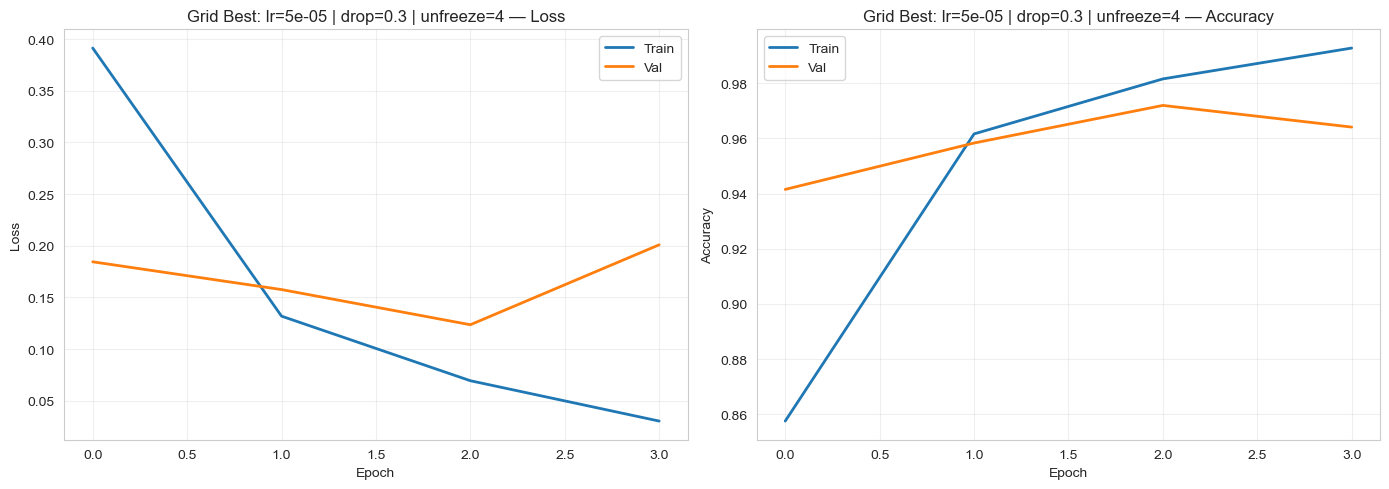

In [8]:
# Reconstruir df_cv com Grid Search 
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Mean_num': accs.mean()})
df_cv = pd.DataFrame(rows).sort_values('Mean_num', ascending=False)
print('Top 5 (incluindo Grid Search):')
print(df_cv[['Modelo', 'Média', 'Std']].head().to_string(index=False))

melhor_nome = df_cv.iloc[0]['Modelo']
print(f'\nMelhor modelo: {melhor_nome}')

# Determinar hiperparâmetros 
is_grid = melhor_nome.startswith('Grid Best:')
if is_grid:
    g = best_grid  
    final_lr = g['lr']
    final_drop = g['drop']
    final_unfreeze = g['unfreeze_n']
    final_mname = best_mname
    final_freeze = best_freeze
    print(f'  Hiperparâmetros: lr={final_lr}, drop={final_drop}, unfreeze={final_unfreeze}')
else:
    # Veio do K-Fold inicial
    for nome, mname, freeze_strat, lr in configs:
        if nome == melhor_nome:
            final_mname = mname; final_freeze = freeze_strat; final_lr = lr; break
    final_drop = 0.3
    final_unfreeze = 2

# Tokenizar para o modelo final
tok_class_final, _, _ = MODELS[final_mname]
tokenizer_final = tok_class_final.from_pretrained(final_mname)

# Split 80/20
idx_all = np.arange(len(textos))
tr_idx, vl_idx, _, _ = train_test_split(
    idx_all, idx_all, test_size=0.20, random_state=42, stratify=labels)

ids_final, mask_final = tokenize_texts(textos, tokenizer_final, MAX_LEN)
tr_ids = ids_final[tr_idx]; tr_mask = mask_final[tr_idx]; tr_labels = y_all[tr_idx]
vl_ids = ids_final[vl_idx]; vl_mask = mask_final[vl_idx]; vl_labels = y_all[vl_idx]
te_data = all_test_tokenized[final_mname]
te_ids = te_data['ids_test']; te_mask = te_data['mask_test']

print(f'  Treino: {len(tr_idx)} | Val: {len(vl_idx)} | Teste: {len(textos_test)}')

torch.manual_seed(42)
melhor_model = TransformerClassifier(
    final_mname, num_classes,
    freeze_strategy=final_freeze,
    unfreeze_last_n=max(final_unfreeze, 1) if final_freeze != 'full' else 1,
    classifier_dropout=final_drop)

t0 = time.time()
val_acc, history = train_transformer(
    melhor_model, tr_ids, tr_mask, tr_labels,
    vl_ids, vl_mask, vl_labels,
    epochs=EPOCHS_FINAL, lr=final_lr, batch_size=BATCH_SIZE)
tempo = time.time() - t0

# Avaliar no teste (em batches para não rebentar VRAM)
test_acc, _ = eval_batched(melhor_model, te_ids, te_mask, y_test)
train_acc, _ = eval_batched(melhor_model, tr_ids, tr_mask, tr_labels)

# Previsões para confusion matrix
melhor_model.eval()
test_preds = []
with torch.no_grad():
    for i in range(0, len(y_test), 64):
        b_ids = te_ids[i:i+64].to(device)
        b_mask = te_mask[i:i+64].to(device)
        test_preds.extend(torch.argmax(melhor_model(b_ids, b_mask), 1).cpu().numpy())
        del b_ids, b_mask
test_preds = np.array(test_preds)

print(f'\n🏆 {melhor_nome}:')
print(f'  Treino:    {train_acc:.2%}')
print(f'  Validação: {val_acc:.2%}')
print(f'  Teste:     {test_acc:.2%}')
print(f'  Tempo:     {tempo:.1f}s')

# ── Curvas de aprendizagem ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (tk, vk), ax, title in [
    (('train_loss', 'val_loss'), axes[0], 'Loss'),
    (('train_acc', 'val_acc'), axes[1], 'Accuracy')]:
    ax.plot(history[tk], label='Train', linewidth=2)
    ax.plot(history[vk], label='Val', linewidth=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'{melhor_nome} — {title}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### **6. Avaliação Final**

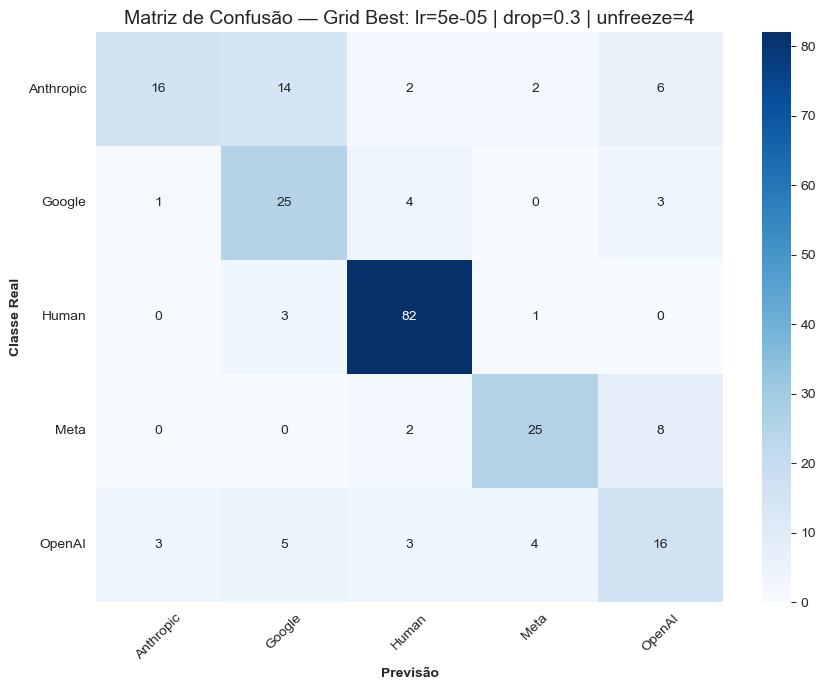


Classification Report — Grid Best: lr=5e-05 | drop=0.3 | unfreeze=4:
              precision    recall  f1-score   support

   Anthropic       0.80      0.40      0.53        40
      Google       0.53      0.76      0.62        33
       Human       0.88      0.95      0.92        86
        Meta       0.78      0.71      0.75        35
      OpenAI       0.48      0.52      0.50        31

    accuracy                           0.73       225
   macro avg       0.70      0.67      0.66       225
weighted avg       0.75      0.73      0.72       225



In [9]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontweight='bold')
plt.ylabel('Classe Real', fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_nome}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(f'\nClassification Report — {melhor_nome}:')
print(classification_report(
    [idx2label[i] for i in y_test],
    [idx2label[i] for i in test_preds],
    zero_division=0))

### **7. Guardar o Modelo**

In [10]:
import pickle
os.makedirs('../models', exist_ok=True)

# Pesos
model_path = '../models/transformer.pth'
torch.save(melhor_model.state_dict(), model_path)
print(f'✅ Pesos guardados em {model_path}')

# Metadados (tudo o que é preciso para reconstruir)
meta = {
    'model_class': 'TransformerClassifier',
    'model_name': final_mname,
    'num_classes': num_classes,
    'class_names': class_names,
    'label2idx': label2idx,
    'idx2label': idx2label,
    'max_len': MAX_LEN,
    'freeze_strategy': final_freeze,
    'unfreeze_last_n': final_unfreeze if final_freeze != 'full' else 0,
    'classifier_dropout': final_drop,
}
if is_grid:
    meta['grid_lr'] = final_lr

meta_path = '../models/transformer.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f'✅ Metadados guardados em {meta_path}')
print(f'\n📋 Modelo: {final_mname} ({final_freeze}, drop={final_drop})')

✅ Pesos guardados em ../models/transformer.pth
✅ Metadados guardados em ../models/transformer.pkl

📋 Modelo: distilbert-base-uncased (partial, drop=0.3)
